In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import numpy as np
import geopandas as gpd

display(HTML("""
<style>
body.vscode-dark .xr-wrap,
body.vscode-high-contrast .xr-wrap {
    --xr-font-color0: #f0f3f6;
    --xr-font-color2: #c9d1d9;
    --xr-font-color3: #9da7b3;
    --xr-border-color: #6e7781;
    --xr-disabled-color: #9da7b3;
    --xr-background-color: #161b22;
    --xr-background-color-row-even: #21262d;
    --xr-background-color-row-odd: #30363d;
    color: var(--xr-font-color0);
}
</style>
"""))

In [4]:
caminho_arquivo = "../data/processed/meteoro-coarsened/100u.nc"
ds = xr.open_dataset(caminho_arquivo, decode_times=False)

shape = gpd.read_file("../data/processed/shapes/estados_ne.shp")
shape_wgs84 = shape.to_crs("EPSG:4326")

longitudes_grade, latitudes_grade = np.meshgrid(
    ds.longitude.values, ds.latitude.values
)

pontos_grade = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(longitudes_grade.ravel(), latitudes_grade.ravel()),
    crs="EPSG:4326",
)

pontos_no_shape = pontos_grade[pontos_grade.within(shape_wgs84.union_all())]

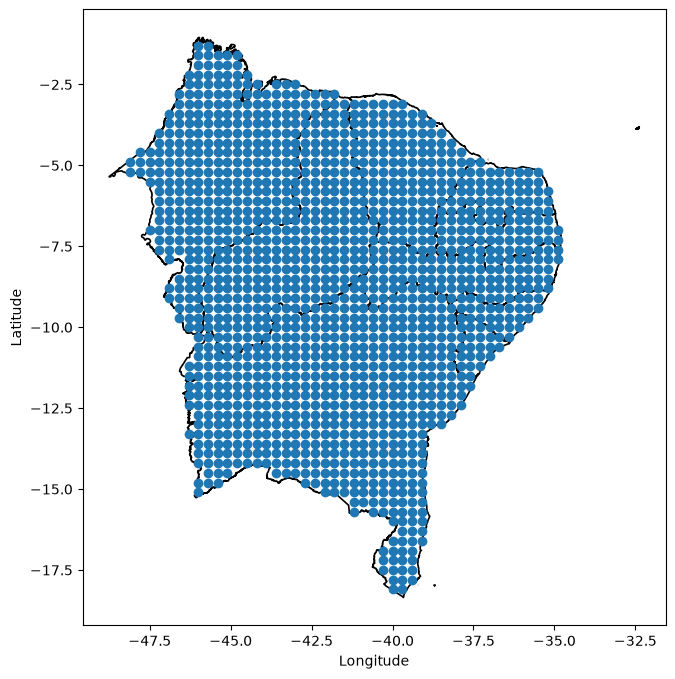

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
shape_wgs84.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)
ax.scatter(
    pontos_no_shape.geometry.x,
    pontos_no_shape.geometry.y
)
ax.set_aspect("equal")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
# ax.set_xlim(-42, -40)
# ax.set_ylim(-20, -10)
plt.show()